<h1 style="text-align:center;
font-size:38px;
background-color:#65789B;
font-weight:bold;
color:white;
padding:20px;">
    Supply Chain Analysis
</h1>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8-whitegrid")

Load Dataset

In [3]:
df = pd.read_csv(r"Dataset\DataCoSupplyChainDataset.csv", encoding="latin-1")

Basic Inspection

In [20]:
df.shape

(180519, 49)

In [14]:
df.sample(3)

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order State,Order Status,Product Card Id,Product Category Id,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
26180,CASH,2,4,35.349998,135.970001,Advance shipping,0,29,Shop By Sport,Caguas,...,Jalisco,CLOSED,627,29,http://images.acmesports.sports/Under+Armour+G...,Under Armour Girls' Toddler Spine Surge Runni,39.990002,0,4/5/2017 21:26,Standard Class
5952,CASH,2,1,71.339996,245.979996,Late delivery,1,43,Camping & Hiking,La Crosse,...,Aragua,CLOSED,957,43,http://images.acmesports.sports/Diamondback+Wo...,Diamondback Women's Serene Classic Comfort Bi,299.980011,0,4/1/2015 16:41,First Class
60544,DEBIT,5,4,31.680000,359.980011,Late delivery,1,45,Fishing,Chicago,...,Paraná,COMPLETE,1004,45,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/26/2015 23:47,Standard Class


In [3]:
df.columns

Index(['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)',
       'Benefit per order', 'Sales per customer', 'Delivery Status',
       'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City',
       'Customer Country', 'Customer Email', 'Customer Fname', 'Customer Id',
       'Customer Lname', 'Customer Password', 'Customer Segment',
       'Customer State', 'Customer Street', 'Customer Zipcode',
       'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market',
       'Order City', 'Order Country', 'Order Customer Id',
       'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id',
       'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id',
       'Order Item Product Price', 'Order Item Profit Ratio',
       'Order Item Quantity', 'Sales', 'Order Item Total',
       'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status',
       'Order Zipcode', 'Product Card Id', 'Product Category Id',
       'Product De

In [23]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.isnull().sum().sort_values(ascending=False).head(5)

Product Description              180519
Order Zipcode                    155679
Customer Lname                        8
Customer Zipcode                      3
Days for shipment (scheduled)         0
dtype: int64

In [11]:
df = df.dropna(axis=1)

In [12]:
df.isnull().sum().sort_values(ascending=False).head(5)

Type                             0
Days for shipping (real)         0
Days for shipment (scheduled)    0
Benefit per order                0
Sales per customer               0
dtype: int64

In [19]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Days for shipping (real),180519.0,3.497654,1.623722,0.000000,2.000000,3.000000,5.000000,6.000000
Days for shipment (scheduled),180519.0,2.931847,1.374449,0.000000,2.000000,4.000000,4.000000,4.000000
Benefit per order,180519.0,21.974989,104.433526,-4274.979980,7.000000,31.520000,64.800003,911.799988
Sales per customer,180519.0,183.107609,120.043670,7.490000,104.379997,163.990005,247.399994,1939.989990
Late_delivery_risk,180519.0,0.548291,0.497664,0.000000,0.000000,1.000000,1.000000,1.000000
Category Id,180519.0,31.851451,15.640064,2.000000,18.000000,29.000000,45.000000,76.000000
Customer Id,180519.0,6691.379495,4162.918106,1.000000,3258.500000,6457.000000,9779.000000,20757.000000
Department Id,180519.0,5.443460,1.629246,2.000000,4.000000,5.000000,7.000000,12.000000
Latitude,180519.0,29.719955,9.813646,-33.937553,18.265432,33.144863,39.279617,48.781933
Longitude,180519.0,-84.915675,21.433241,-158.025986,-98.446312,-76.847908,-66.370583,115.263077


In [25]:
df.describe(include='object').T

,count,unique,top,freq
Type,180519,4,DEBIT,69295
Delivery Status,180519,4,Late delivery,98977
Category Name,180519,50,Cleats,24551
Customer City,180519,563,Caguas,66770
Customer Country,180519,2,EE. UU.,111146
Customer Email,180519,1,XXXXXXXXX,180519
Customer Fname,180519,782,Mary,65150
Customer Password,180519,1,XXXXXXXXX,180519
Customer Segment,180519,3,Consumer,93504
Customer State,180519,46,PR,69373


---

<div style="background:#FFF8E1;
padding:12px;
border-radius:8px;
border-left:6px solid #F9A825;">

<strong>Question 1</strong>

Which shipping modes have the highest rate of late deliveries, and by how much do actual shipping days exceed scheduled days?

</div>

In [92]:
df["dealayDays"] =  df["Days for shipping (real)"] - df["Days for shipment (scheduled)"]

temp = df.groupby(["Shipping Mode"]).agg(
    totalOrders = ("Order Id","count"),
    totalLateDeliveries = ("Late_delivery_risk","sum"),
    avgDelayDays = ("dealayDays", "mean")
)
temp["lateDeliveryRate"] = (temp["totalLateDeliveries"]/temp["totalOrders"])*100
temp = temp.sort_values(by="lateDeliveryRate",ascending=False).reset_index()
temp

,Shipping Mode,totalOrders,totalLateDeliveries,avgDelayDays,lateDeliveryRate
0,First Class,27814,26513,1.000000,95.322499
1,Second Class,35216,26987,1.990828,76.632781
2,Same Day,9737,4454,0.478279,45.743042
3,Standard Class,107752,41023,-0.004093,38.071683


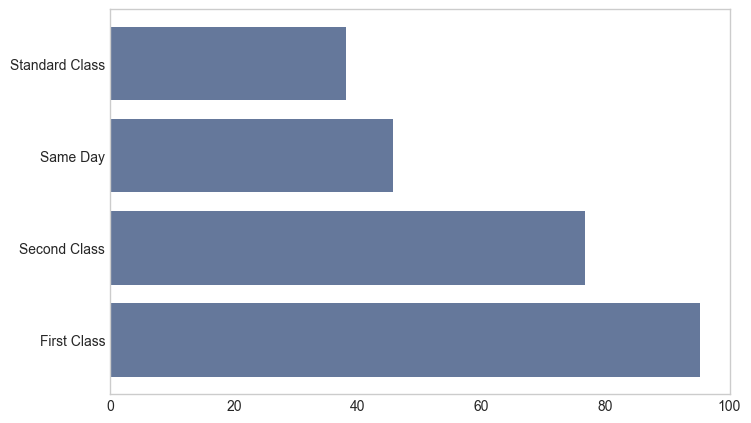

In [93]:
plt.figure(figsize=(8, 5))
plt.barh(
    temp["Shipping Mode"],
    temp["lateDeliveryRate"],
    color="#65789B"
)

plt.grid(False)
plt.show()

<div style="background:#E8F5E9;
padding:12px;
border-left:6px solid #43A047;
border-radius:8px;">

<strong>Findings</strong>

<ul>
<li>First Class shipping had the highest late delivery rate (95.3%), making it the least reliable shipping mode.</li>
<li>Second Class shipments experienced the largest average delay (1.99 days) beyond the scheduled delivery time.</li>
<li>Standard Class was the most reliable option, with the lowest late delivery rate (38.1%) and almost no average delay.</li>
<li>The results indicate that premium shipping modes are more prone to delivery delays than Standard Class shipments.</li>
</ul>

</div>

---

<div style="background:#FFF8E1;
padding:12px;
border-radius:8px;
border-left:6px solid #F9A825;">

<strong>Question 2</strong>

Which product categories generate the most profit per order, and which are operating at a loss despite high sales volume?

</div>

In [6]:
temp = df.groupby(["Category Name"]).agg(
    totalProfitPerOrder = ("Benefit per order","sum"),
    avgProfitPerOrder = ("Benefit per order","mean"),
    totalSales = ("Sales","sum")
)
temp["profit%"] = round((temp["totalProfitPerOrder"] / temp["totalSales"])*100,2)
temp["sales%"] = round((temp["totalSales"] / df["Sales"].sum())*100,2)
temp.sort_values(by = "avgProfitPerOrder",ascending=False).reset_index().head(10)

,Category Name,totalProfitPerOrder,avgProfitPerOrder,totalSales,profit%,sales%
0,Computers,69656.810171,157.594593,6.630000e+05,10.51,1.80
1,Garden,33443.010106,69.097128,2.577687e+05,12.97,0.70
2,Crafts,25531.170060,52.750351,2.233563e+05,11.43,0.61
3,Cameras,30289.799946,51.165203,2.676077e+05,11.32,0.73
4,Fishing,756220.767190,43.649106,6.929654e+06,10.91,18.84
5,Children's Clothing,27178.099597,41.684202,2.328292e+05,11.67,0.63
6,Sporting Goods,12518.610119,35.066135,1.170068e+05,10.70,0.32
7,Music,14436.319923,33.263410,1.131221e+05,12.76,0.31
8,Camping & Hiking,427455.568106,31.135230,4.118426e+06,10.38,11.20
9,Consumer Electronics,13223.399926,30.680742,1.089913e+05,12.13,0.30


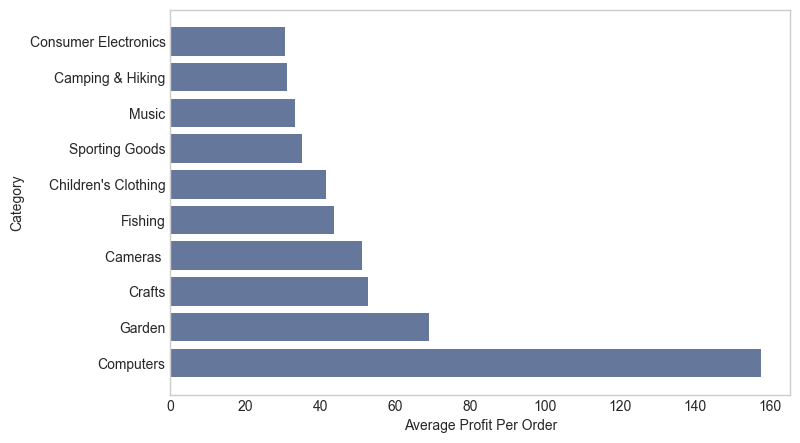

In [7]:
top10 = temp.nlargest(10, "avgProfitPerOrder")

plt.figure(figsize=(8, 5))
plt.barh(
    top10.index,
    top10["avgProfitPerOrder"],
    color="#65789B"
)

plt.xlabel("Average Profit Per Order")
plt.ylabel("Category")

plt.grid(False)
plt.show()

<div style="background:#E8F5E9;
padding:12px;
border-left:6px solid #43A047;
border-radius:8px;">

<strong>Findings</strong>

<ul>
<li>
Computers generated the highest average profit per order (157.59), significantly outperforming all other categories.
</li>
<li>
Garden, Crafts, and Cameras also delivered strong profit per order, indicating high-margin product segments.
</li>
<li>
Fishing was the strongest overall performer, contributing 18.84% of total sales while maintaining a healthy profit margin of 10.91%.
</li>
<li>
Cleats, Camping & Hiking, and Cardio Equipment were major revenue contributors, each accounting for over 10% of total sales.
</li>
<li>
No product category showed a negative total profit, indicating that none of the categories are currently operating at a loss.
</li>
</ul>

</div>

---

<div style="background:#FFF8E1;
padding:12px;
border-radius:8px;
border-left:6px solid #F9A825;">

<strong>Question 3</strong>

How does discount rate affect order profitability — is there a discount threshold beyond which orders become unprofitable?

</div>

In [8]:
df["Order Item Discount Rate"].value_counts()

Order Item Discount Rate
0.04    10029
0.05    10029
0.06    10029
0.07    10029
0.09    10029
0.10    10029
0.12    10029
0.13    10029
0.15    10029
0.16    10029
0.17    10029
0.18    10029
0.20    10029
0.25    10029
0.03    10029
0.00    10028
0.01    10028
0.02    10028
Name: count, dtype: int64

In [9]:
df["Order Item Discount Rate"].describe()

count    180519.000000
mean          0.101668
std           0.070415
min           0.000000
25%           0.040000
50%           0.100000
75%           0.160000
max           0.250000
Name: Order Item Discount Rate, dtype: float64

In [10]:
bins = [0, 0.1, 0.2, 0.25]
labels = ['0-10%', '10-20%', '20-25%']
df['discountBucket'] = pd.cut(df["Order Item Discount Rate"], bins=bins, labels=labels)

In [11]:
df["discountBucket"].value_counts()

discountBucket
0-10%     80230
10-20%    70203
20-25%    20058
Name: count, dtype: int64

In [12]:
temp = df.groupby(["discountBucket"]).agg(
    avgProfitPerOrder = ("Order Item Profit Ratio","mean"),
).sort_values(by = "avgProfitPerOrder",ascending=False).reset_index()
temp

C:\Users\ajoyj\AppData\Local\Temp\ipykernel_23592\515028453.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  temp = df.groupby(["discountBucket"]).agg(


,discountBucket,avgProfitPerOrder
0,0-10%,0.122042
1,20-25%,0.119724
2,10-20%,0.118343


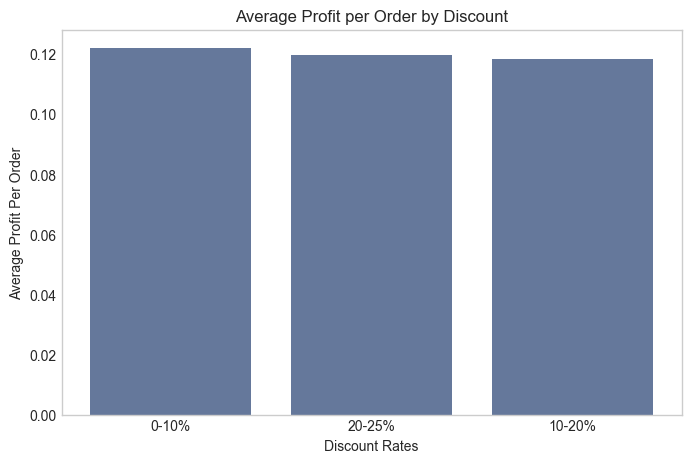

In [13]:
plt.figure(figsize=(8, 5))
plt.bar(
    temp["discountBucket"],
    temp["avgProfitPerOrder"],
    color="#65789B"
)

plt.xlabel("Discount Rates")
plt.ylabel("Average Profit Per Order")
plt.title("Average Profit per Order by Discount")

plt.grid(False)
plt.show()

<div style="background:#E8F5E9;
padding:12px;
border-left:6px solid #43A047;
border-radius:8px;">

<strong>Findings</strong>

<ul>
<li>
Orders remain profitable across all analyzed discount ranges, with average profit ratios staying close to 12%.
</li>
<li>
The 0–10% discount bucket delivers the highest profitability (12.20%).
</li>
<li>
Profitability declines slightly in the 10–20% range, but the difference is minimal.
</li>
<li>
No clear discount threshold was identified where profitability turns negative.
</li>

</ul>

</div>

---

<div style="background:#FFF8E1;
padding:12px;
border-radius:8px;
border-left:6px solid #F9A825;">

<strong>Question 4</strong>

Which markets have the highest proportion of cancelled and suspected fraud orders, and what is the revenue at risk?

</div>

In [14]:
cancelledOrders = df[(df["Order Status"] == "SUSPECTED_FRAUD") | (df["Order Status"] == "CANCELED")]

In [15]:
temp1 = cancelledOrders.groupby(["Market"]).agg(
    totalCancelledAndFraudOrders = ("Order Status","count"),
    revenuePerMarket = ("Sales","sum")
).sort_values(by = "totalCancelledAndFraudOrders",ascending=False).reset_index()

In [16]:
temp2 = df.groupby(["Market"]).agg(
    totalOrders = ("Order Id","count"),
    totalRevenue = ("Sales","sum")
).sort_values(by = "totalOrders",ascending=False).reset_index()

In [17]:
temp3 = pd.merge(temp1,temp2,on="Market")

In [18]:
temp3["cancelledAndFraudOrdersProportion"] = round((temp3["totalCancelledAndFraudOrders"]/temp3["totalOrders"])*100,2)
temp3["revenueProportion"] = round((temp3["revenuePerMarket"]/temp3["totalRevenue"])*100,2)

In [19]:
temp3 = temp3[["Market", "cancelledAndFraudOrdersProportion", "revenueProportion"]].sort_values(by="cancelledAndFraudOrdersProportion",ascending=False)

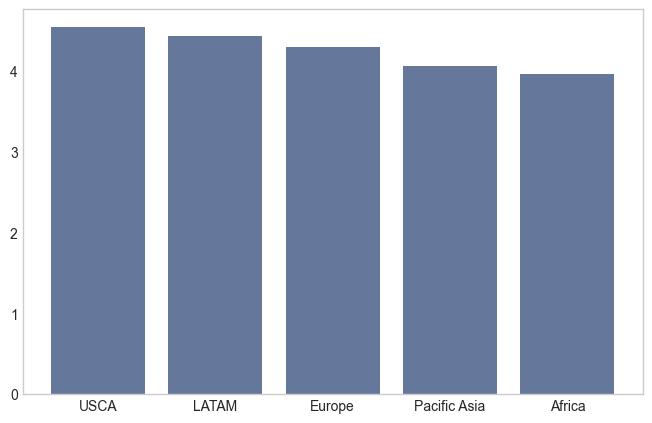

In [20]:
plt.figure(figsize=(8, 5))
plt.bar(
    temp3["Market"],
    temp3["cancelledAndFraudOrdersProportion"],
    color="#65789B"
)

plt.grid(False)
plt.show()

<div style="background:#E8F5E9;
padding:12px;
border-left:6px solid #43A047;
border-radius:8px;">

<strong>Findings</strong>

<ul>
<li>
USCA recorded the highest proportion of cancelled and suspected fraud orders (4.54% of all orders), making it the riskiest market in the dataset.
</li>
<li>
LATAM (4.43%) and Europe (4.30%) also showed elevated levels of cancellation and fraud activity.
</li>
<li>
Africa had the lowest risk proportion among the analyzed markets (3.96%).
</li>
<li>
Approximately 4–5% of revenue in each market is exposed to cancellation or fraud-related risk.
</li>

</ul>

</div>

---

<div style="background:#FFF8E1;
padding:12px;
border-radius:8px;
border-left:6px solid #F9A825;">

<strong>Question 5</strong>

Which customer segments have the highest average order value and best profit margins?

</div>

In [21]:
temp = df.groupby(["Customer Segment"]).agg(
    avgOrderValue = ("Order Item Total","mean"),
    avgProfirPerOrder = ("Benefit per order","mean"),
    profitMargin = ("Order Item Profit Ratio","mean")
).reset_index()

temp["avgOrderValue"] = temp["avgOrderValue"].round().astype(int)
temp["avgProfirPerOrder"] = temp["avgProfirPerOrder"].round().astype(int)
temp["profitMargin"] = (temp["profitMargin"]*100).round(2)

temp.sort_values(by="avgOrderValue",ascending=False)

,Customer Segment,avgOrderValue,avgProfirPerOrder,profitMargin
0,Consumer,184,22,12.12
1,Corporate,183,22,12.09
2,Home Office,182,21,11.86


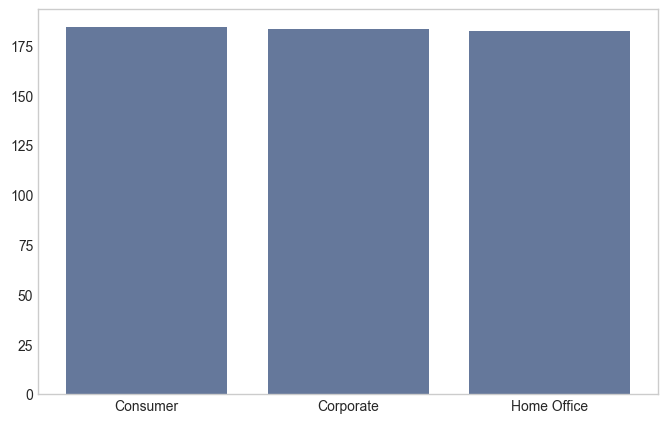

In [22]:
plt.figure(figsize=(8, 5))
plt.bar(
    temp["Customer Segment"],
    temp["avgOrderValue"],
    color="#65789B"
)

plt.grid(False)
plt.show()

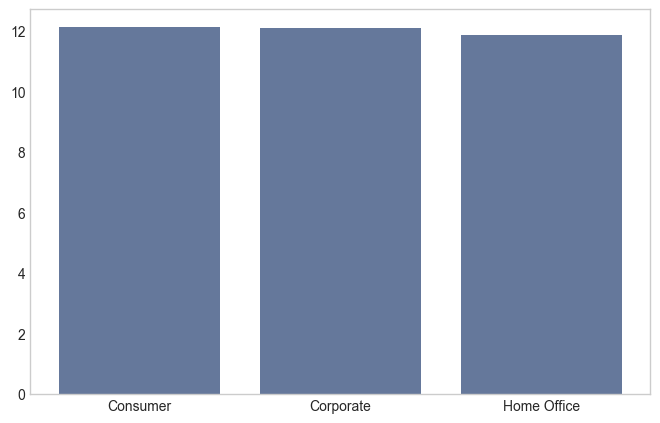

In [23]:
temp = temp.sort_values(by="profitMargin",ascending=False)
plt.figure(figsize=(8, 5))
plt.bar(
    temp["Customer Segment"],
    temp["profitMargin"],
    color="#65789B"
)

plt.grid(False)
plt.show()

<div style="background:#E8F5E9;
padding:12px;
border-left:6px solid #43A047;
border-radius:8px;">

<strong>Findings</strong>

<ul>
<li>
Consumer customers generated the highest average order value (184) among all customer segments.
</li>
<li>
Consumer customers also achieved the highest profit margin (12.12%), making them the most profitable segment overall.
</li>
<li>
Corporate customers closely followed with an average order value of 183 and a profit margin of 12.09%.
</li>
<li>
Home Office customers recorded the lowest average order value (182) and profit margin (11.86%), though the difference was minimal.
</li>
<li>
The results suggest that the business does not depend heavily on a single customer segment for profitability, indicating a balanced revenue structure.
</li>

</ul>

</div>

---

<div style="background:#FFF8E1;
padding:12px;
border-radius:8px;
border-left:6px solid #F9A825;">

<strong>Question 6</strong>

Which top 10 customers by revenue have declining order frequency in the most recent period compared to the prior period?

</div>

In [24]:
mask = df.groupby(["Customer Id"]).agg(
    totalOrders = ("Order Id","count"),
    totalSales = ("Sales","sum")
).sort_values(by=["totalSales"], ascending=False).reset_index().head(10)["Customer Id"]

In [25]:
df['orderDate'] = pd.to_datetime(df['order date (DateOrders)'])
df["orderQuater"] = df['orderDate'].dt.quarter
df["orderMonth"] = df['orderDate'].dt.month
df["orderYear"] = df['orderDate'].dt.year

In [26]:
temp = df[df["Customer Id"].isin(mask)]

In [27]:
temp = temp.groupby(["Customer Id", "orderYear"]).agg(
    totalOrders = ("Order Id","count")
).reset_index()

In [28]:
temp

,Customer Id,orderYear,totalOrders
0,791,2015,27
1,791,2016,9
2,791,2017,7
3,1288,2015,11
4,1288,2016,18
5,1288,2017,13
6,1657,2015,20
7,1657,2016,15
8,1657,2017,7
9,2641,2015,10


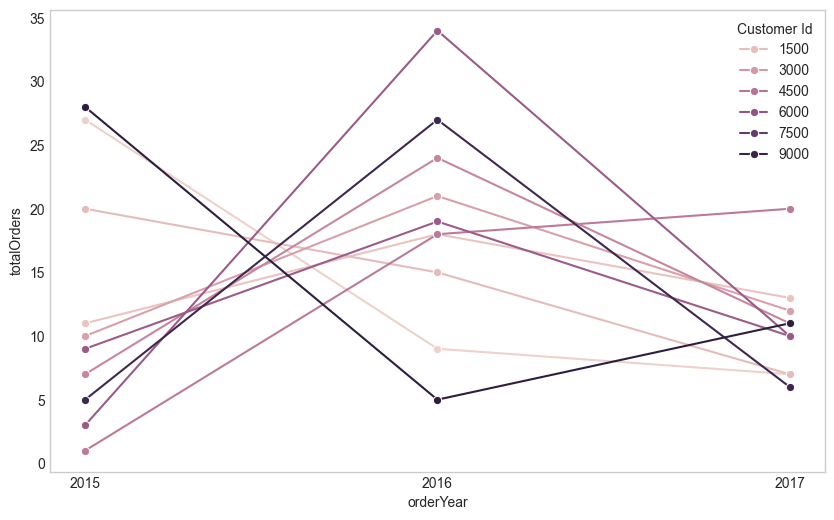

In [29]:
# Convert to string
temp['orderYear'] = temp['orderYear'].astype(str)

# Explicit category order
year_order = ['2015', '2016', '2017']

plt.figure(figsize=(10, 6))

sns.lineplot(
    data=temp,
    x='orderYear',
    y='totalOrders',
    hue='Customer Id',
    marker='o',
    sort=False
)

plt.xticks(ticks=range(len(year_order)), labels=year_order)
plt.grid(False)
plt.show()

<div style="background:#E8F5E9;
padding:12px;
border-left:6px solid #43A047;
border-radius:8px;">

<strong>Findings</strong>

<ul>
<li>
Among the top 10 customers by revenue, 8 customers showed a decline in order frequency from 2016 to 2017.
</li>
<li>
The most significant decline was observed for Customer 5654, whose order count dropped from 34 to 10 orders (−24 orders).
</li>
<li>
Customer 8766 experienced the second-largest decline, falling from 27 to 6 orders (−21 orders).
</li>
<li>
Only Customer 4249 and Customer 9371 increased their order frequency in the most recent year.
</li>
<li>
The concentration of declining order activity among several top-revenue customers may indicate potential customer retention risks and should be investigated further.
</li>

</ul>

</div>

---

<div style="background:#FFF8E1;
padding:12px;
border-radius:8px;
border-left:6px solid #F9A825;">

<strong>Question 7</strong>

What percentage of orders are delivered late by market, and which markets show a worsening trend over time?

</div>

In [30]:
temp = df.groupby(["Market","orderYear"]).agg(
    totalLateOrders = ("Late_delivery_risk","sum"),
    totalOrders = ("Order Id","count")
).reset_index()

In [31]:
temp

,Market,orderYear,totalLateOrders,totalOrders
0,Africa,2016,5708,10356
1,Africa,2017,632,1258
2,Europe,2015,13806,24914
3,Europe,2016,2151,3872
4,Europe,2017,11786,21466
5,LATAM,2015,14047,25775
6,LATAM,2017,13997,25819
7,Pacific Asia,2015,6519,11961
8,Pacific Asia,2016,12496,22641
9,Pacific Asia,2017,2502,4535


In [32]:
temp["lateDelivery%"] = round((temp["totalLateOrders"]/temp["totalOrders"])*100,2)

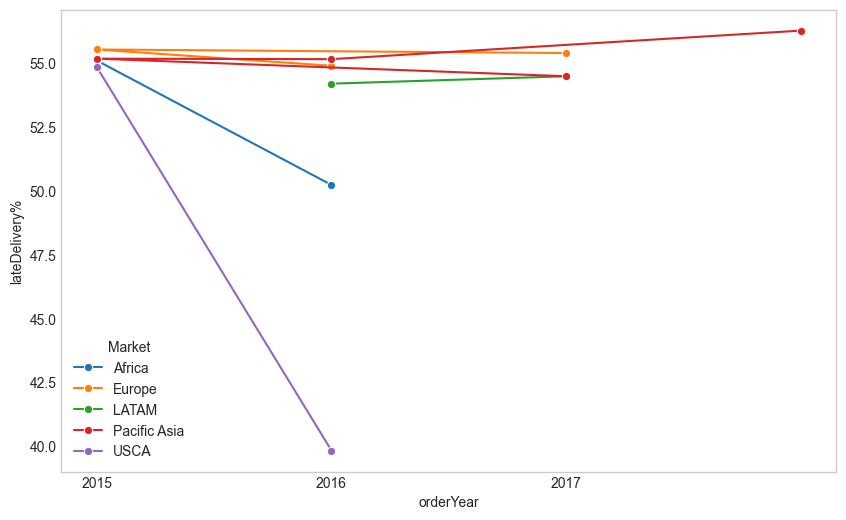

In [33]:
# Convert to string
temp['orderYear'] = temp['orderYear'].astype(str)

# Explicit category order
year_order = ['2015', '2016', '2017']

plt.figure(figsize=(10, 6))

sns.lineplot(
    data=temp,
    x='orderYear',
    y='lateDelivery%',
    hue='Market',
    marker='o',
    sort=False
)

plt.xticks(ticks=range(len(year_order)), labels=year_order)
plt.grid(False)
plt.show()

<div style="background:#E8F5E9;
padding:12px;
border-left:6px solid #43A047;
border-radius:8px;">

<strong>Findings</strong>

<ul>
<li>
Late delivery rates are consistently high across all markets, averaging around 54–55% of total orders.
</li>
<li>
Pacific Asia shows the most persistent worsening trend, increasing from 54.50% (2015) to approximately 55.19% (2016) and remaining elevated in 2017.
</li>
<li>
Africa improved from 55.12% to 50.24%, indicating better delivery performance in the most recent year.
</li>
<li>
Europe remained relatively stable, with late delivery rates consistently around 55%.
</li>
<li>
USCA recorded a sharp drop in late deliveries during 2017; however, the result is based on a very small number of orders (118) and should be interpreted cautiously.
</li>
<li>
Overall, late deliveries affect more than half of all orders across most markets, suggesting a significant supply chain performance challenge.
</li>

</ul>

</div>

---

<div style="background:#FFF8E1;
padding:12px;
border-radius:8px;
border-left:6px solid #F9A825;">

<strong>Question 8</strong>

For orders that were shipped late, how many days on average were customers waiting beyond the promised delivery date, broken down by department?

</div>

In [34]:
temp = df[df["Delivery Status"] == "Late delivery"]

In [35]:
temp["delay"] = temp["Days for shipping (real)"] - temp["Days for shipment (scheduled)"] 

C:\Users\ajoyj\AppData\Local\Temp\ipykernel_23592\1333852658.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  temp["delay"] = temp["Days for shipping (real)"] - temp["Days for shipment (scheduled)"]


In [36]:
temp1 = temp.groupby(["Department Name"]).agg(
    avgDelay = ("delay","mean"),
).sort_values(by=["avgDelay"], ascending=False).reset_index()

In [37]:
temp1["avgDelay"] = temp1["avgDelay"].round(2)

In [38]:
temp1

,Department Name,avgDelay
0,Fitness,1.63
1,Technology,1.63
2,Outdoors,1.63
3,Apparel,1.63
4,Golf,1.62
5,Discs Shop,1.62
6,Fan Shop,1.61
7,Footwear,1.61
8,Pet Shop,1.60
9,Book Shop,1.53


<div style="background:#E8F5E9;
padding:12px;
border-left:6px solid #43A047;
border-radius:8px;">

<strong>Findings</strong>

<ul>
<li>
Customers waited approximately 1.5 to 1.6 days beyond the promised delivery date across all departments.
</li>
<li>
Fitness, Technology, Outdoors, and Apparel recorded the highest average delays, each averaging about 1.63 days beyond the scheduled delivery date.
</li>
<li>
Health and Beauty and Book Shop showed the lowest average delays, at approximately 1.51–1.53 days.
</li>
<li>
The consistency of delay times suggests that late deliveries are likely driven by broader logistics or shipping issues rather than department-specific operational problems.
</li>

</ul>

</div>

---

<div style="background:#FFF8E1;
padding:12px;
border-radius:8px;
border-left:6px solid #F9A825;">

<strong>Question 9</strong>

Is there a correlation between order quantity and discount rate? Are bulk orders receiving disproportionately large discounts?

</div>

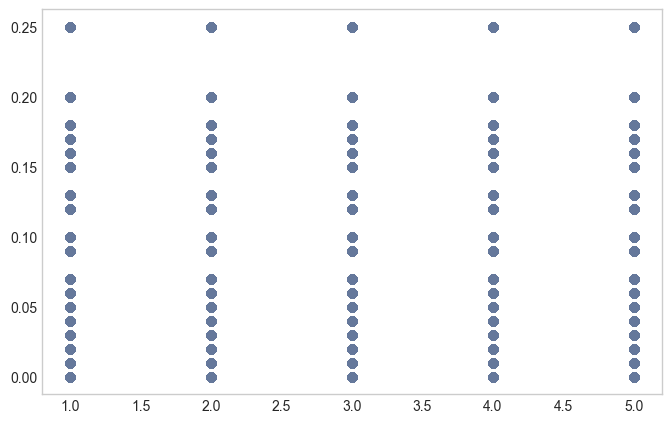

In [39]:
plt.figure(figsize=(8, 5))
plt.scatter(
    df["Order Item Quantity"],
    df["Order Item Discount Rate"],
    color="#65789B"
)

plt.grid(False)
plt.show()

In [40]:
df[["Order Item Quantity", "Order Item Discount Rate"]].corr()

,Order Item Quantity,Order Item Discount Rate
Order Item Quantity,1.000000,-0.000028
Order Item Discount Rate,-0.000028,1.000000


<div style="background:#E8F5E9;
padding:12px;
border-left:6px solid #43A047;
border-radius:8px;">

<strong>Findings</strong>

<ul>
<li>
The correlation between order quantity and discount rate is -0.000028, effectively zero.
</li>
<li>
There is no meaningful relationship between the number of items purchased and the discount applied.
</li>
<li>
Customers placing larger orders do not appear to receive systematically higher discounts than customers purchasing fewer items.
</li>
<li>
No evidence was found to suggest that bulk orders receive disproportionately large discounts.
</li>

</ul>

</div>

---

<div style="background:#FFF8E1;
padding:12px;
border-radius:8px;
border-left:6px solid #F9A825;">

<strong>Question 10</strong>

Which order regions have the longest average time between order placement and shipment, and how does this compare to the scheduled commitment?

</div>

In [41]:
df['shipping date (DateOrders)'] = pd.to_datetime(df['shipping date (DateOrders)'])

In [42]:
df["dateDiff"] = (df["shipping date (DateOrders)"] - df['orderDate']).dt.days

In [43]:
df.groupby(["Order Region"]).agg(
    avgDateDiff = ("dateDiff","mean"),
    avgDaysForShipment = ("Days for shipment (scheduled)","mean")
).sort_values(by=["avgDateDiff"], ascending=False).reset_index()

,Order Region,avgDateDiff,avgDaysForShipment
0,Central Africa,3.546213,2.920692
1,West Africa,3.510552,2.983496
2,Eastern Asia,3.500275,2.960852
3,East Africa,3.492441,2.943844
4,Central America,3.486010,2.948520
5,Eastern Europe,3.484439,2.920918
6,Northern Europe,3.479984,2.955474
7,West of USA,3.478794,2.947704
8,Caribbean,3.478240,2.960688
9,South America,3.477603,2.949381


<div style="background:#E8F5E9;
padding:12px;
border-left:6px solid #43A047;
border-radius:8px;">

<strong>Findings</strong>

<ul>
<li>
Central Africa recorded the longest average time between order placement and shipment (3.55 days), followed by West Africa (3.51 days) and Eastern Asia (3.50 days).
</li>
<li>
Canada had the shortest average shipment lead time (3.32 days) among all regions.
</li>
<li>
The largest gap between actual and scheduled shipment time was observed in Central Africa, where shipments took approximately 0.63 days longer than planned.
</li>
<li>
The consistency of shipment delays across regions suggests that shipping inefficiencies may stem from broader operational processes rather than isolated regional issues.
</li>

</ul>

</div>

<div style="background:#FFF8E1;
padding:12px;
border-radius:8px;
border-left:6px solid #F9A825;">

<strong>Question 11</strong>

What is the year-over-year revenue trend by market, and which markets are growing vs declining?

</div>

In [44]:
df.groupby("orderYear").agg(
    orders=("Order Id","count"),
    revenue=("Sales","sum")
)

,orders,revenue
orderYear,,
2015,62650,1.234083e+07
2016,62550,1.230382e+07
2017,53196,1.180844e+07
2018,2123,3.316501e+05


In [45]:
temp = (
    df.groupby(["Market", "orderYear"])
      .agg(totalRevenue=("Sales", "sum"))
      .sort_index()
)

temp["lagRevenue"] = (
    temp.groupby(level="Market")["totalRevenue"]
        .shift(1)
)

temp["yoy"] = (
    (temp["totalRevenue"] - temp["lagRevenue"])
    / temp["lagRevenue"]
) * 100

temp

totalRevenue    lagRevenue         yoy
Market       orderYear                                        
Africa       2016       2.046623e+06           NaN         NaN
             2017       2.478302e+05  2.046623e+06  -87.890775
Europe       2015       4.913405e+06           NaN         NaN
             2016       7.613233e+05  4.913405e+06  -84.505180
             2017       5.197668e+06  7.613233e+05  582.714913
LATAM        2015       5.072188e+06           NaN         NaN
             2017       5.205424e+06  5.072188e+06    2.626793
Pacific Asia 2015       2.355238e+06           NaN         NaN
             2016       4.452406e+06  2.355238e+06   89.042746
             2017       1.134450e+06  4.452406e+06  -74.520507
             2018       3.316501e+05  1.134450e+06  -70.765569
USCA         2016       5.043466e+06           NaN         NaN
             2017       2.306319e+04  5.043466e+06  -99.542711

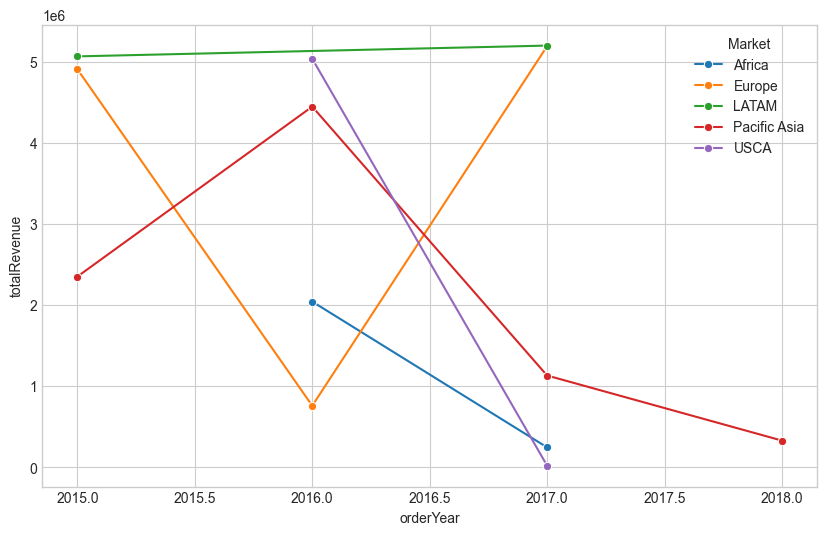

In [46]:
plt.figure(figsize=(10,6))

sns.lineplot(
    data=temp.reset_index(),
    x="orderYear",
    y="totalRevenue",
    hue="Market",
    marker="o"
)

plt.show()

<div style="background:#FFF8E1;
padding:12px;
border-radius:8px;
border-left:6px solid #F9A825;">

<strong>Question 12</strong>

Which product category have the highest cancellation rate, and does this correlate with the discount rate offered?

</div>

In [47]:
temp = df[df["Order Status"] == "CANCELED"]

In [48]:
a = temp.groupby(["Category Name"]).agg(
    totalCancelledOrders = ("Order Status","count")
).reset_index()

In [49]:
b = df.groupby(["Category Name"]).agg(
    totalOrders = ("Order Id","count"),
    avgDiscount = ("Order Item Discount Rate","mean")
)

In [50]:
c = pd.merge(a, b, on='Category Name', how='inner')

In [51]:
c["cancelRate"] = round((c["totalCancelledOrders"]/c["totalOrders"])*100,2)

In [52]:
c.sort_values(by = "cancelRate",ascending=False).head(10)

,Category Name,totalCancelledOrders,totalOrders,avgDiscount,cancelRate
13,Consumer Electronics,17,431,0.101694,3.94
29,Kids' Golf Clubs,15,384,0.096745,3.91
1,As Seen on TV!,2,68,0.109412,2.94
14,Crafts,14,484,0.101694,2.89
40,Toys,15,529,0.101682,2.84
22,Golf Balls,39,1475,0.101003,2.64
42,Video Games,22,838,0.102088,2.63
34,Music,11,434,0.101359,2.53
37,Sporting Goods,9,357,0.102353,2.52
39,Tennis & Racquet,8,328,0.102256,2.44


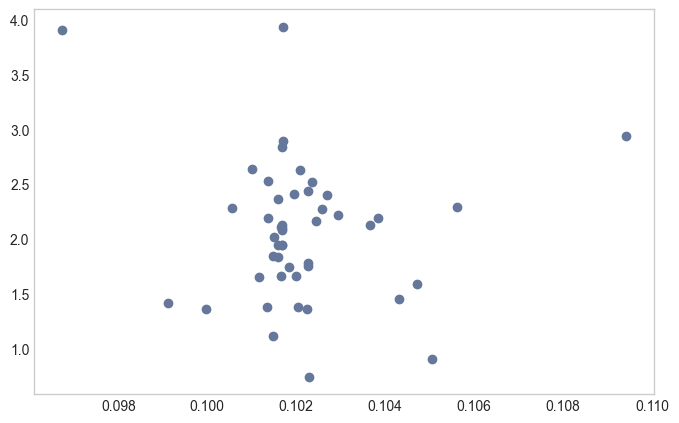

In [53]:
plt.figure(figsize=(8, 5))
plt.scatter(
    c["avgDiscount"],
    c["cancelRate"],
    color="#65789B"
)

plt.grid(False)
plt.show()

In [54]:
c[["avgDiscount","cancelRate"]].corr()

,avgDiscount,cancelRate
avgDiscount,1.000000,-0.107012
cancelRate,-0.107012,1.000000


<div style="background:#E8F5E9;
padding:12px;
border-left:6px solid #43A047;
border-radius:8px;">

<strong>Findings</strong>

<ul>
<li>
Consumer Electronics recorded the highest cancellation rate (3.94%), closely followed by Kids' Golf Clubs (3.91%).
</li>
<li>
Average discount rates across categories are highly similar, generally clustering around 10%.
</li>
<li>
Categories with higher cancellation rates do not consistently offer higher discounts than categories with lower cancellation rates.
</li>
<li>
Based on the available evidence, discounting does not appear to be a major driver of order cancellations.
</li>

</ul>

</div>

---

<div style="background:#FFF8E1;
padding:12px;
border-radius:8px;
border-left:6px solid #F9A825;">

<strong>Question 13</strong>

What share of total revenue comes from the top 20% of customers (Pareto analysis), and how do their buying patterns differ?

</div>

In [55]:
df["Customer Id"].nunique()*0.20

4130.400000000001

In [56]:
temp = df.groupby(["Customer Id"]).agg(
    totalSales = ("Sales","sum"),
).sort_values(by="totalSales",ascending=False).head(4130)

In [57]:
(temp["totalSales"].sum()/df["Sales"].sum())*100

np.float64(49.90597230954335)

In [58]:
top20 = temp.head(4130).index

In [59]:
df["customerGroup"] = np.where(
    df["Customer Id"].isin(top20),
    "Top 20%",
    "Bottom 80%"
)

comparison = df.groupby(
    "customerGroup"
).agg(
    avgOrderValue=("Order Item Total","mean"),
    avgQuantity=("Order Item Quantity","mean"),
    avgDiscount=("Order Item Discount Rate","mean"),
    avgProfit=("Benefit per order","mean")
)

comparison

,avgOrderValue,avgQuantity,avgDiscount,avgProfit
customerGroup,,,,
Bottom 80%,181.272711,2.062738,0.101839,21.564211
Top 20%,184.987303,2.194121,0.101493,22.395795


<div style="background:#E8F5E9;
padding:12px;
border-left:6px solid #43A047;
border-radius:8px;">

<strong>Findings</strong>

<ul>
<li>
The top 20% of customers contribute approximately 49.9% of total revenue.
</li>
<li>
Revenue concentration is moderate, indicating that the business is not overly dependent on a small group of customers.
</li>
<li>
The observed distribution does not follow the traditional 80/20 Pareto rule, where 20% of customers generate around 80% of revenue.
</li>
<li>
The highest-revenue customer generated approximately 10.5K in sales, while the remaining top customers generated between 8.7K and 9.3K.
</li>

</ul>

</div>

---

<div style="background:#FFF8E1;
padding:12px;
border-radius:8px;
border-left:6px solid #F9A825;">

<strong>Question 14</strong>

Are there specific weekdays or months where late deliveries spike — suggesting seasonal or operational patterns?

</div>

In [60]:
df["weekday"] = df["orderDate"].dt.day_name()

In [61]:
temp = df.groupby(["weekday"]).agg(
    totalOrders = ("Order Id","count"),
    totalLateDeliveries = ("Late_delivery_risk","sum")
).reset_index()

temp["lateRate"] = round((temp["totalLateDeliveries"]/temp["totalOrders"])*100,2)

In [62]:
temp1 = df.groupby(["orderMonth"]).agg(
    totalOrders = ("Order Id","count"),
    totalLateDeliveries = ("Late_delivery_risk","sum")
).reset_index()

temp1["lateRate"] = round((temp1["totalLateDeliveries"]/temp1["totalOrders"])*100,2)

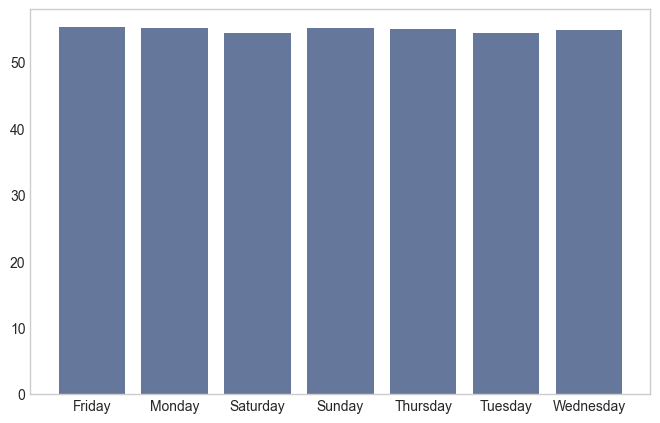

In [63]:
plt.figure(figsize=(8, 5))
plt.bar(
    temp["weekday"],
    temp["lateRate"],
    color="#65789B"
)

plt.grid(False)
plt.show()

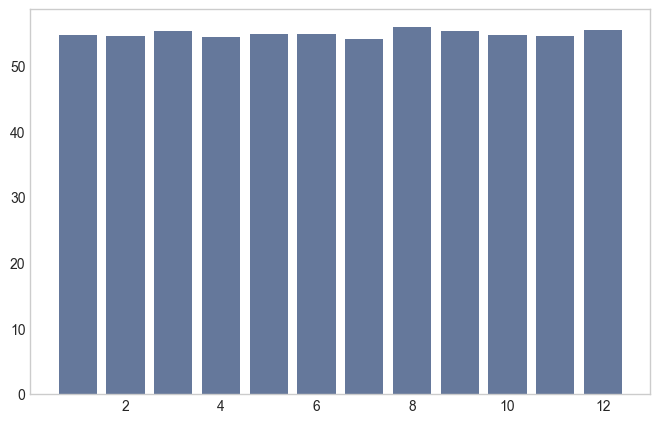

In [64]:
plt.figure(figsize=(8, 5))
plt.bar(
    temp1["orderMonth"],
    temp1["lateRate"],
    color="#65789B"
)

plt.grid(False)
plt.show()

<div style="background:#E8F5E9;
padding:12px;
border-left:6px solid #43A047;
border-radius:8px;">

<strong>Findings</strong>

<ul>
<li>
Late deliveries are distributed relatively evenly across weekdays and months, suggesting no major weekday-specific operational bottlenecks.
</li>

</div>

---

<div style="background:#FFF8E1;
padding:12px;
border-radius:8px;
border-left:6px solid #F9A825;">

<strong>Question 15</strong>


Which departments have the lowest profit-per-order ratio, and is low profit explained by high discounting or high product cost?

</div>

In [79]:
lowDept = df.groupby(["Department Name"]).agg(
    ppo = ("Order Item Profit Ratio","mean"),
    avgdiscount = ("Order Item Discount Rate","mean"),
    avgPrice = ("Order Item Product Price","mean")
).sort_values(by="ppo").head(5).reset_index()

print("Departments having low ppo =",lowDept["Department Name"].tolist())
print("Average Discount Rate of Departments having low ppo =",round(lowDept["avgdiscount"].mean()*100,2),"%")
print("Average Product Cost of Departments having low ppo =",round(lowDept["avgPrice"].mean()))

Departments having low ppo = ['Book Shop', 'Pet Shop', 'Health and Beauty ', 'Discs Shop', 'Golf']
Average Discount Rate of Departments having low ppo = 10.17 %
Average Product Cost of Departments having low ppo = 114


In [80]:
highDept = df.groupby(["Department Name"]).agg(
    ppo = ("Order Item Profit Ratio","mean"),
    avgdiscount = ("Order Item Discount Rate","mean"),
    avgPrice = ("Order Item Product Price","mean")
).sort_values(by="ppo",ascending=False).head(6).reset_index()
print("Departments having high ppo =",highDept["Department Name"].tolist())
print("Average Discount Rate of Departments having high ppo =",round(highDept["avgdiscount"].mean()*100,2),"%")
print("Average Product Cost of Departments having high ppo =",round(highDept["avgPrice"].mean()))

Departments having high ppo = ['Fitness', 'Technology', 'Outdoors', 'Apparel', 'Fan Shop', 'Footwear']
Average Discount Rate of Departments having high ppo = 10.18 %
Average Product Cost of Departments having high ppo = 218


<div style="background:#E8F5E9;
padding:12px;
border-left:6px solid #43A047;
border-radius:8px;">

<strong>Findings</strong>

<ul>
<li>
The departments with the lowest average profit-per-order ratio are Book Shop, Pet Shop, Health and Beauty, Discs Shop, and Golf.
</li>
<li>
These low-profit departments offer an average discount of 10.17%, which is nearly identical to the 10.18% average discount observed in the highest-profit departments.
</li>
<li>
The similarity in discount levels indicates that high discounting is not the primary reason for low profitability.
</li>
<li>
Low-profit departments have a substantially lower average product price (113.62) compared to high-profit departments (217.81).
</li>

</ul>

</div>

---

<div style="background:#FFF8E1;
padding:12px;
border-radius:8px;
border-left:6px solid #F9A825;">

<strong>Question 16</strong>

How does the late delivery risk vary across different combinations of shipping mode and order region — which combinations are the highest risk?

</div>

In [83]:
temp = df.groupby(["Shipping Mode","Order Region"]).agg(
    deliveryRisk = ("Late_delivery_risk","sum")
).sort_values(by="deliveryRisk",ascending=False)

In [84]:
temp.head(1)

,,deliveryRisk
Shipping Mode,Order Region,
Standard Class,Central America,6571


In [85]:
temp.unstack()

deliveryRisk                                           \
Order Region         Canada Caribbean Central Africa Central America   
Shipping Mode                                                          
First Class             170      1132            278            4185   
Same Day                  7       224             24             651   
Second Class            125      1277            241            4111   
Standard Class          166      1782            429            6571   

                                                                  \
Order Region   Central Asia East Africa East of USA Eastern Asia   
Shipping Mode                                                      
First Class              63         277        1050          989   
Same Day                 13          41         200          193   
Second Class            101         279         956         1116   
Standard Class          129         439        1643         1657   

                                            ...                            \
Order Region   Eastern Europe North Africa  ... South Asia South of  USA    
Shipping Mode                               ...                             
First Class               632          472  ...       1240            571   
Same Day                   64          108  ...        188            100   
Second Class              578          483  ...       1198            673   
Standard Class            908          699  ...       1724            912   

                                                                          \
Order Region   Southeast Asia Southern Africa Southern Europe US Center    
Shipping Mode                                                              
First Class              1482             195            1462        951   
Same Day                  184              42             303        125   
Second Class             1395             102            1293        905   
Standard Class           2236             278            2071       1271   

                                                                  
Order Region   West Africa West Asia West of USA  Western Europe  
Shipping Mode                                                     
First Class            453       947         1072           4107  
Same Day                79       128          205            708  
Second Class           570       921         1254           4236  
Standard Class         851      1326         1782           6089  

[4 rows x 23 columns]

<div style="background:#E8F5E9;
padding:12px;
border-left:6px solid #43A047;
border-radius:8px;">

<strong>Findings</strong>

<ul>
<li>
Standard Class shipments to Central America recorded the highest number of late deliveries (6,571), representing the largest operational risk volume.
</li>
<li>
Western Europe also experienced a high concentration of late deliveries, particularly for Standard Class (6,089) shipments.
</li>
<li>
Across nearly all regions, Standard Class generated the greatest number of late-delivery incidents.
</li>
<li>
The combination of shipping mode and geographic region plays a significant role in delivery performance, with Standard Class shipments showing the highest exposure to delays.
</li>

</ul>

</div>

---

<div style="background:#FFF8E1;
padding:12px;
border-radius:8px;
border-left:6px solid #F9A825;">

<strong>Question 17</strong>

What is the average profit per order by customer segment and shipping mode — are certain segment-mode combinations significantly more valuable?

</div>

In [ ]:
df.groupby(["Customer Segment","Shipping Mode"]).agg(
    avgProfitPerOrder = ("Order Profit Per Order","mean")
).unstack()

avgProfitPerOrder                                        
Shipping Mode          First Class    Same Day Second Class Standard Class
Customer Segment                                                          
Consumer                204.846386  199.694604   203.789601     204.620729
Corporate               204.431344  198.278952   202.650301     204.603946
Home Office             200.984876  201.128164   200.801176     203.301441

<div style="background:#E8F5E9;
padding:12px;
border-left:6px solid #43A047;
border-radius:8px;">

<strong>Findings</strong>

<ul>
<li>
Consumer customers using First Class shipping generated the highest average profit per order (24.81), making them the most valuable customer segment–shipping mode combination.
</li>
<li>
Consumer customers using Same Day shipping produced the lowest average profit per order (20.08).
</li>
<li>
Profitability differences across customer segments were relatively modest, with most combinations ranging between 20 and 25 profit per order.
</li>
<li>
No customer segment–shipping mode combination exhibits exceptionally high or exceptionally low profitability, suggesting a generally balanced profit structure across the business.
</li>

</ul>

</div>

---

<div style="background:#FFF8E1;
padding:12px;
border-radius:8px;
border-left:6px solid #F9A825;">

<strong>Question 18</strong>

Are orders with higher product prices more likely to be delivered on time, suggesting premium products get priority handling?

</div>

In [69]:
df["Order Item Product Price"].describe()

count    180519.000000
mean        141.232550
std         139.732492
min           9.990000
25%          50.000000
50%          59.990002
75%         199.990005
max        1999.989990
Name: Order Item Product Price, dtype: float64

In [90]:
premeuimProducts = df[df["Order Item Product Price"] >= 500]
print("Average late delivery risk of premeuim products =",round(premeuimProducts["Late_delivery_risk"].mean()*100,2),"%")

Average late delivery risk of premeuim products = 53.4 %


In [91]:
basicProducts = df[df["Order Item Product Price"] < 500]
print("Average late delivery risk of non-premeuim products =",round(basicProducts["Late_delivery_risk"].mean()*100,2),"%")

Average late delivery risk of non-premeuim products = 54.84 %


<div style="background:#E8F5E9;
padding:12px;
border-left:6px solid #43A047;
border-radius:8px;">

<strong>Findings</strong>

<ul>
<li>
Premium products (priced ₹500 and above) experienced a late-delivery rate of 53.40%.
</li>
<li>
Non-premium products (priced below ₹500) experienced a slightly higher late-delivery rate of 54.84%.
</li>
<li>
Premium products showed a 1.44 percentage-point lower delivery risk compared to non-premium products. The difference in delivery performance between premium and non-premium products is relatively small.
</li>
<li>
While premium products appear to be delivered on time slightly more often, the evidence is not strong enough to conclude that they receive systematic priority handling.
</li>

</ul>

</div>

---

<div style="background:#FFF8E1;
padding:12px;
border-radius:8px;
border-left:6px solid #F9A825;">

<strong>Question 19</strong>

Which cities generate the highest number of high-value orders, and are they being served with adequate shipping speed?
</div>

In [98]:
threshold = (
    df["Order Item Total"]
    .quantile(0.75)
)

In [101]:
high_value = df[df["Order Item Total"] >= threshold]


temp = high_value.groupby("Customer City").agg(
        highValueOrders=("Order Id","count"),
        avgLateDelivery=("Late_delivery_risk","mean")
    ).sort_values("highValueOrders",ascending=False)

temp.head(10)

,highValueOrders,avgLateDelivery
Customer City,,
Caguas,16609,0.548197
Chicago,972,0.566872
Los Angeles,856,0.542056
Brooklyn,828,0.527778
New York,432,0.500000
Bronx,394,0.558376
Philadelphia,387,0.540052
San Diego,367,0.531335
Miami,319,0.517241


<div style="background:#E8F5E9;
padding:12px;
border-left:6px solid #43A047;
border-radius:8px;">

<strong>Findings</strong>

<ul>
<li>
Caguas generated by far the highest number of high-value orders (16,609 orders), significantly exceeding all other cities in the dataset.
</li>
<li>
Other major contributors of high-value orders include Chicago (972), Los Angeles (856), and Brooklyn (828).
</li>
<li>
High-value customers across all major cities experience relatively high late-delivery rates, generally ranging between 50% and 57%.
</li>
<li>
Delivery performance appears broadly similar across major high-value customer locations, suggesting that premium revenue-generating areas are not receiving substantially better service levels.
</li>

</ul>

</div>

---

<div align="right">

*Author: Ajoy Jayarajan*

</div>